In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [30]:
# Chargement du fichier et nettoyage des lignes vides
df = pd.read_csv("../dataset/etudiant_multi_var.csv")
df = df.dropna()

In [31]:
# Choix des facteurs (X) et de la note à prédire (y)
X = df[['Heures', 'Sommeil', 'Stress', 'Participation', 'Sport', 'Ecran']]
y = df['Note']

In [32]:
# Création de l'intelligence du modèle et apprentissage
model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:

print("=== RÉSULTATS DU MODÈLE ===")
print(f"Note de départ (Intercept): {model.intercept_:.4f}\n")

=== RÉSULTATS DU MODÈLE ===
Note de départ (Intercept): 9.8180



In [34]:

# Affichage de l'influence de chaque colonne sur la note finale
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Impact'])
print("Impact de chaque facteur :")
print(coefficients)

Impact de chaque facteur :
                 Impact
Heures         0.306185
Sommeil        0.140017
Stress        -0.170969
Participation  0.075789
Sport          0.005991
Ecran          0.008968


In [35]:
# Calcul des prédictions pour vérifier si le modèle s'est trompé
y_pred = model.predict(X)

In [36]:
# Calcul de l'erreur (MSE) et du score de précision (R²)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

In [37]:
print(f"\nErreur moyenne (MSE): {mse:.4f}")
print(f"Score de précision (R²): {r2:.4f}")


Erreur moyenne (MSE): 0.0031
Score de précision (R²): 0.9821


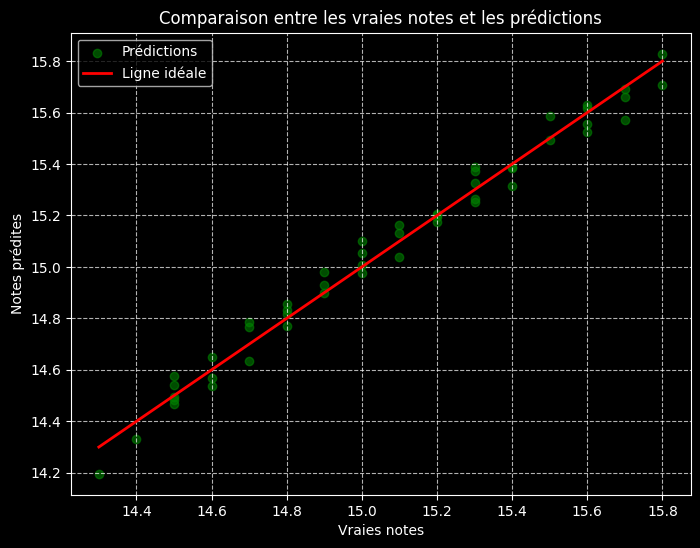

In [38]:
# Création du graphique pour comparer le "Réel" et le "Prédit"
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='green', alpha=0.6, label="Prédictions")
# Ligne rouge : représente la perfection (prédiction = réalité)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', lw=2, label="Ligne idéale")
plt.title("Comparaison entre les vraies notes et les prédictions")
plt.xlabel("Vraies notes")
plt.ylabel("Notes prédites")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()